This notebook runs in silico perturbation using the **90/10 count-decoder** checkpoint from notebook 3 and `docs/examples/configs/perturbation.yaml`.

| Piece | Path |
|---|---|
| count ckpt | `T_perturb/res/count_split/checkpoints/20260819_0949...epoch=24.ckpt` |
| 90m source tokens | `T_perturb/tokenized_data/lps_90min_perturb/` (notebook 02, `REFERENCE_TIME=90m_LPS`) |
| dump | sod2 `.../res/perturbation/il1b_src_90m` (same policy as notebook 04 embeddings) |
| `context_mode` | `true` (must match 90/10 training) |

Do **not** point this at `LPS_all_tps_2k` (normal source): IL1B is ~0 at rest, so src-KO would skip almost every batch.


In the LPS time-course dataset, we first used PerturbGen’s time-resolved gene embeddings to identify transcriptional programs that change over the trajectory. Clustering embeddings across time highlighted a cytokine/chemokine program that was strongly induced early after LPS, with IL1B emerging as a central, highly responsive gene in myeloid lineages (e.g., CD14⁺/CD16⁺ monocytes and dendritic cells). See notebook 5 for GP dicovery.

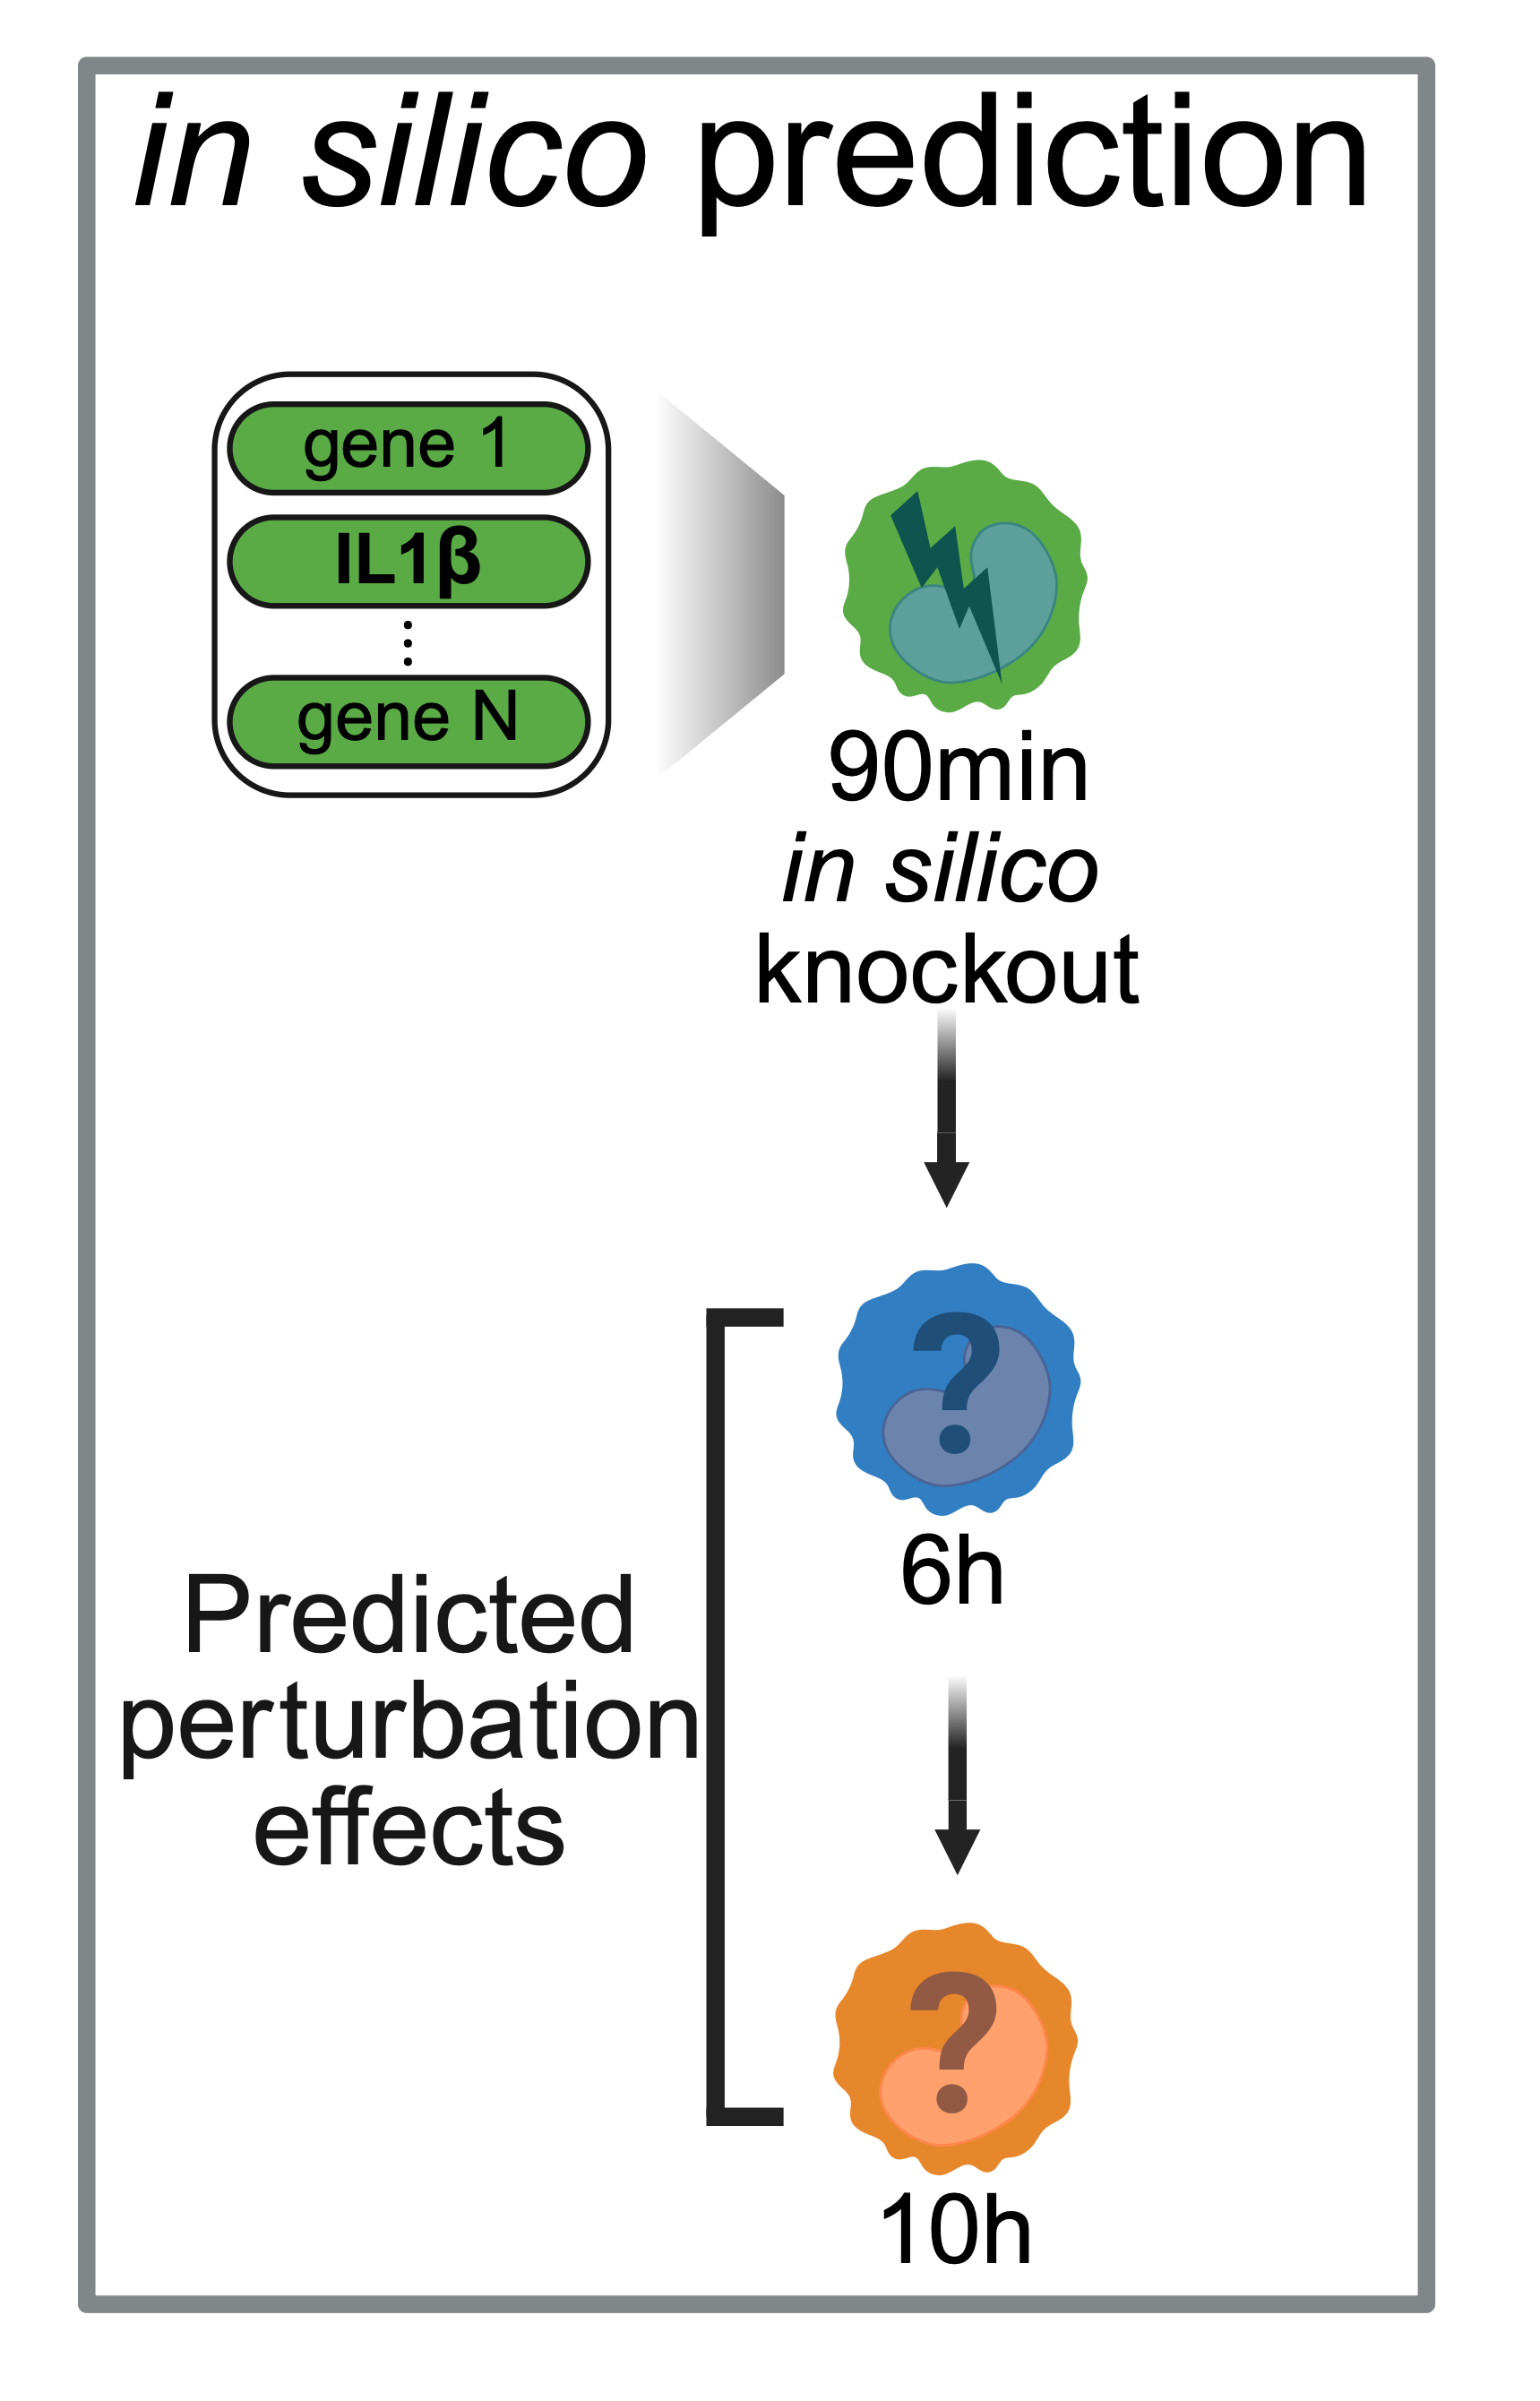

In [1]:
from pathlib import Path
from IPython.display import Image, display

fig2 = Path("../_static/fig2.png")
if fig2.is_file():
    display(Image(filename=str(fig2)))
else:
    print(f"Skipping missing tutorial figure: {fig2.resolve()}")

Based on this, we chose IL1B as a mechanistic candidate to test whether an early inflammatory driver can propagate effects downstream along the response trajectory. Following the schematic in Fig. above, we then performed an in silico IL1B knockout at the 90-minute time point (i.e., editing the 90-min source state), and used PerturbGen to predict the downstream transcriptional consequences at 6 hours and 10 hours. Concretely, we run two forward passes—control vs. IL1B-perturbed—starting from matched 90-min cells (with the same conditioning context), and quantify the perturbation effect at 6 h and 10 h by comparing predicted expression profiles (e.g., DEGs / pathway shifts) between the two predicted futures.

## 6.1. Config

Edit `docs/examples/configs/perturbation.yaml` if you change genes, times, or GPUs.
The YAML already points at the 90/10 count ckpt and the sod2 dump dir. Tokenized 90m files must exist (re-run notebook 02 with `DATASET_NAME = "lps_90min_perturb"` if they are missing).


> **⚠️ The source state must express the perturbed gene.**
>
> This example knocks out IL1B (`ENSG00000125538`) at the **source** (`perturbation_sequence: "src"`). A src-knockout only has an effect if the gene is expressed in the source state: cells without the gene token in the source are filtered out, and any batch left with no qualifying cells is skipped (`No cells with perturbed genes ... Skipping test step.`).
>
> IL1B is LPS-induced and ~0 in the unstimulated `normal` baseline, so this config uses the **`90m_LPS`** source (tokenize with `REFERENCE_TIME = "90m_LPS"` / `DATASET_NAME = "lps_90min_perturb"`; see notebook 02). Pointing this at a `normal` source would skip nearly all batches and produce empty / irreproducible results.

PerturbGen perturbations are defined through a lightweight YAML configuration file, with a ready-to-use template provided in the /config folder. This design allows users to run reproducible in silico perturbation experiments without modifying model code.
The key parameter controlling perturbations is:

```yaml
genes_to_perturb:
  - "ENSG00000125538"

This field specifies which gene(s) are perturbed in the source or specified time state. Each entry can be provided as either:
	•	an Ensembl gene ID (recommended for unambiguous mapping), or
	•	a gene symbol (e.g. "IL1B").

In the current example, "ENSG00000125538" corresponds to IL1B, which we perturb at the 90-minute time point to assess how early disruption of IL1 signaling propagates to later stages of the immune response (6 h and 10 h).

Importantly, genes_to_perturb accepts a list, enabling simulation of:
	•	single-gene perturbations (e.g. IL1B alone), or
	•	multi-gene perturbations (e.g. combinatorial knockouts or pathway-level interventions).


In addition to specifying which genes to perturb, the configuration template allows users to control where along the sequence the perturbation is applied via the perturbation_sequence field:
```yaml
perturbation_sequence:
  - "src"

This parameter defines which sequence is edited before prediction, and can take one of two values:
	•	"src" (source perturbation)
The perturbation is applied to the source state (e.g. the normal or 90-minute LPS condition depending on how you defined your source in the tokenization step). The model then predicts how this early intervention propagates to downstream target states (e.g. 6 h and 10 h).
This is the default and biologically most relevant setting for studying causal, trajectory-level effects, such as early signaling disruptions that reshape later cell states.
	•	"tgt" (target perturbation)
The perturbation is applied directly to the target state being predicted. This setting is useful for within-state perturbation analysis or for comparisons with models that do not explicitly model state transitions.

PerturbGen separates where a perturbation is applied from which time points are predicted, allowing flexible experimental designs along a trajectory.

Predicting downstream time points
The pred_tps field specifies which time points the model should generate:

```yaml
pred_tps:
  - 1
  - 2

These indices refer to the ordered time points defined for the dataset. In the LPS experiment, this corresponds to:
	0 → 90 minutes
	1 → 6 hours
	2 → 10 hours.
In this example 90 min has been considered as source. So, it instructs PerturbGen to predict transcriptional states at 6 h and 10 h, using the earlier 90-minute state as conditioning input. Both predictions are produced for control and perturbed runs, enabling direct comparison of downstream effects.

When perturbation_sequence is set to "tgt", an additional parameter becomes relevant:
```yaml
pert_tps:
  - 1

This field specifies which target time point(s) are perturbed, rather than the source. For example, with:
```yaml
perturbation_sequence:
  - "tgt"
pert_tps:
  - 1

the perturbation would be applied directly at time point 1 (6 h) before predicting the corresponding output. (if source has been selected as 90m and not normal).

Importantly, pert_tps is ignored when perturbation_sequence = "src", since source perturbations are applied upstream (e.g. at 90 minutes) and automatically propagated to all predicted downstream time points listed in pred_tps.

PerturbGen supports multiple perturbation modes, which control how the specified gene tokens are edited in the sequence. This is configured via:
```yaml
perturbation_mode:
  - "mask"

The following modes are supported:
["mask", "pad", "delete", "overexpress"]

Each mode corresponds to a different biological interpretation:

- `mask`: The gene token is replaced with a `[MASK]` token. This simulates a loss-of-function (knockout/knockdown) by removing gene-specific information while allowing the model to infer downstream consequences from context. This is the default and recommended mode for most in silico KO experiments.
- `pad`: The gene token is replaced with a `[PAD]` token, effectively removing it from the active sequence. This also represents a knockout-like perturbation, but with a stronger assumption that the gene is entirely absent from the expressed gene set.
- `delete`: The gene token is completely removed from the sequence. This enforces the strongest form of gene deletion, reducing sequence length and eliminating any residual representation of the gene. This mode is useful for stress-testing robustness of perturbation effects.
- `overexpress`: The gene token is moved to the top rank of the gene sequence, simulating gene overexpression or activation (e.g., CRISPRa). Because the tokenizer encodes relative expression via rank, promoting a gene to the highest rank increases its inferred regulatory influence on downstream states.

In practice:

- `mask`, `pad`, and `delete` simulate gene knockout or inhibition (CRISPR KO / CRISPRi-like scenarios).
- `overexpress` simulates gene activation or overexpression (CRISPRa-like scenarios).


## 6.2. Perturbation (GPU required)

Run in silico perturbation (prediction) using `val.py` and a YAML config.


This uses the repository script at `perturbgen/Perturb/val.py`.


In [1]:
from pathlib import Path
import yaml

# val.py chdirs to workspace ROOT; YAML relative paths are from here.
WORKSPACE = Path("/home/stuke1/perturbgen")
REPO = WORKSPACE / "Perturbgen"
SOD2 = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

VAL_SCRIPT = str(REPO / "perturbgen" / "Perturb" / "val.py")
CONFIG_PATH = str(REPO / "docs" / "examples" / "configs" / "perturbation.yaml")

print("WORKSPACE:", WORKSPACE)
print("SOD2:", SOD2)
print("VAL_SCRIPT:", VAL_SCRIPT)
print("CONFIG_PATH:", CONFIG_PATH)
assert Path(VAL_SCRIPT).is_file(), VAL_SCRIPT
assert Path(CONFIG_PATH).is_file(), CONFIG_PATH

cfg = yaml.safe_load(Path(CONFIG_PATH).read_text())
src = WORKSPACE / cfg["data"]["src_dataset_file"]
src_adata = WORKSPACE / cfg["data"]["src_adata"]
tgt = WORKSPACE / cfg["data"]["tgt_dataset_folder"]
ckpt = WORKSPACE / cfg["model"]["ckpt_masking_path"]
out_dir = Path(cfg["trainer"]["output_dir"])
print("src_dataset:", src)
print("src_adata:", src_adata)
print("tgt_dataset_folder:", tgt)
print("count ckpt:", ckpt)
print("output_dir:", out_dir)
print("context_mode:", cfg["trainer"].get("context_mode"))
assert str(out_dir).startswith("/mnt/sod2-project/csb4"), out_dir
assert ckpt.is_file(), f"missing count ckpt: {ckpt}"
# HuggingFace save_to_disk writes a directory (not a single file).
if not src.is_dir():
    raise FileNotFoundError(
        f"missing 90m source tokens (HF dataset dir): {src}\n"
        "Re-run notebook 02 with DATASET_NAME='lps_90min_perturb' and REFERENCE_TIME='90m_LPS'."
    )
assert src_adata.is_file(), f"missing 90m source h5ad: {src_adata}"
assert tgt.is_dir(), f"missing 90m target dataset folder: {tgt}"
out_dir.mkdir(parents=True, exist_ok=True)


WORKSPACE: /home/stuke1/perturbgen
SOD2: /mnt/sod2-project/csb4/stuke1/perturbgen
VAL_SCRIPT: /home/stuke1/perturbgen/Perturbgen/perturbgen/Perturb/val.py
CONFIG_PATH: /home/stuke1/perturbgen/Perturbgen/docs/examples/configs/perturbation.yaml
src_dataset: /home/stuke1/perturbgen/T_perturb/tokenized_data/lps_90min_perturb/dataset_2000_hvg_src/90m_LPS.dataset
src_adata: /home/stuke1/perturbgen/T_perturb/tokenized_data/lps_90min_perturb/h5ad_pairing_2000_hvg_src/90m_LPS.h5ad
tgt_dataset_folder: /home/stuke1/perturbgen/T_perturb/tokenized_data/lps_90min_perturb/dataset_2000_hvg_tgt
count ckpt: /home/stuke1/perturbgen/T_perturb/res/count_split/checkpoints/20260819_0949_cellgen_train_count_lr_0.001_wd_0.001_batch_128_drop_0.1_zinb_tp_1-2-3_s_0_pos_time_pos_sin_m_pow-epoch=24.ckpt
output_dir: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/perturbation/il1b_src_90m
context_mode: True


In [2]:
cmd = [
    "python", VAL_SCRIPT,
    "--config", CONFIG_PATH,
]

print(" ".join(cmd))


python /home/stuke1/perturbgen/Perturbgen/perturbgen/Perturb/val.py --config /home/stuke1/perturbgen/Perturbgen/docs/examples/configs/perturbation.yaml


In [3]:
import os
import subprocess
from pathlib import Path

# Headless + run from workspace so YAML relative paths resolve (val.py also chdirs to ROOT).
# HWLOC/DISPLAY fixes avoid "No protocol specified" on headless GPU nodes.
os.chdir(WORKSPACE)
os.environ["CUDA_VISIBLE_DEVICES"] = os.environ.get("CUDA_VISIBLE_DEVICES", "3")
os.environ["MPLBACKEND"] = "Agg"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["HWLOC_COMPONENTS"] = "-gl"
os.environ["HWLOC_GL_LINUX_NVIDIA_DISABLE"] = "1"
os.environ["WANDB_MODE"] = "disabled"
os.environ.pop("DISPLAY", None)
os.environ.pop("WAYLAND_DISPLAY", None)
Path("/tmp/matplotlib").mkdir(parents=True, exist_ok=True)
Path("/tmp/numba_cache").mkdir(parents=True, exist_ok=True)

print("Launching perturbation on GPU", os.environ["CUDA_VISIBLE_DEVICES"])
print(" ".join(cmd))
print(
    "Note: full lps_90min_perturb src is ~148k cells × 2 forwards (control+KO); "
    "first batches can take a few minutes after 'Start datamodule'."
)

# Stream stdout/stderr so progress is visible (avoid looking hung → KeyboardInterrupt).
proc = subprocess.Popen(
    cmd,
    cwd=str(WORKSPACE),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise subprocess.CalledProcessError(ret, cmd)
print("Perturbation finished successfully.")


Launching perturbation on GPU 3
python /home/stuke1/perturbgen/Perturbgen/perturbgen/Perturb/val.py --config /home/stuke1/perturbgen/Perturbgen/docs/examples/configs/perturbation.yaml
Note: full lps_90min_perturb src is ~148k cells × 2 forwards (control+KO); first batches can take a few minutes after 'Start datamodule'.
Current working directory: /home/stuke1/perturbgen
Seed set to 42
Loading 3_10h_LPS.h5ad...
/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Loading 2_6h_LPS.h5ad...
/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Loading 1_normal.h5ad...
Loading 3_10h_LPS.dataset...
Loading 1_normal.dataset...
Loading 2_6h_LPS.dataset...

## 6.3. Analyse IL1B KO effect (control vs perturbed predictions)

Load the AnnData written by §6.2 and quantify the **in silico KO effect**:

- `adata.X` = predicted counts **with** IL1B masked in the 90m source (`pert`)
- `adata.layers["pred_counts"]` = matched **control** predictions (no KO)
- `adata.layers["true_counts"]` = measured target counts (sanity-check control quality only)

Compare `pert − control` at **6h** and **10h** (optionally within CD14 monocytes). There is no experimental IL1B-KO ground truth in this LPS dataset — the KO effect is counterfactual.

In [4]:
from pathlib import Path
import pickle

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

WORKSPACE = Path("/home/stuke1/perturbgen")
SOD2 = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")
OUT_DIR = SOD2 / "T_perturb" / "res" / "perturbation" / "il1b_src_90m"
LEGACY_DIR = WORKSPACE / "T_perturb" / "res" / "perturbation" / "il1b_src_90m"
hits = sorted(OUT_DIR.glob("*_minference_adata_gENSG00000125538_ssrc_tmask.h5ad"))
if not hits:
    hits = sorted(LEGACY_DIR.glob("*_minference_adata_gENSG00000125538_ssrc_tmask.h5ad"))
    OUT_DIR = LEGACY_DIR
    print("No sod2 dump yet; using workspace copy:", OUT_DIR)
assert hits, f"no perturbation h5ad under {OUT_DIR} or {LEGACY_DIR}"
H5AD_PATH = hits[-1]
print("Loading:", H5AD_PATH)

adata = ad.read_h5ad(H5AD_PATH)
# X holds perturbed (KO) counts from return_perturbation_adata
adata.layers["pert_counts"] = np.asarray(adata.X).copy()
print(adata)
print(adata.obs["time_after_LPS"].value_counts())

Loading: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/perturbation/il1b_src_90m/20260827-08:45_minference_adata_gENSG00000125538_ssrc_tmask.h5ad
AnnData object with n_obs × n_vars = 20783 × 2000
    obs: 'cell_type_harmonized', 'cell_pairing_index', 'time_after_LPS', 'cell_idx'
    uns: 'gene_cos_similarity', 'gene_cos_similarity_genes'
    obsm: 'mean_cos_similarity', 'perturbed_cls', 'true_cls'
    layers: 'pred_counts', 'true_counts', 'pert_counts'
time_after_LPS
6h_LPS     11808
10h_LPS     8975
Name: count, dtype: int64


In [5]:

# Ensembl -> symbol (mapping file is symbol -> ENSG)
ensembl_map_path = (
    WORKSPACE
    / "Perturbgen"
    / "perturbgen"
    / "pp"
    / "ensembl_mapping_dict_gc95M.pkl"
)
sym2ens = pickle.load(open(ensembl_map_path, "rb"))
ens2sym = {v: k for k, v in sym2ens.items()}
adata.var["gene_symbol"] = [ens2sym.get(g, g) for g in adata.var_names.astype(str)]
print("IL1B symbol:", adata.var.loc["ENSG00000125538", "gene_symbol"])

IL1B symbol: ENSG00000125538


In [6]:
from IPython.display import display


def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=np.float64)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n, dtype=np.float64)
    out[order] = np.clip(q, 0, 1)
    return out


def effect_table(
    adata: ad.AnnData,
    time_label: str,
    cell_type: str | None = "CD14 monocytes",
    eps: float = 1e-3,
) -> pd.DataFrame:
    """Per-gene KO effect: pert (X) vs control (pred_counts)."""
    mask = adata.obs["time_after_LPS"].astype(str) == time_label
    if cell_type is not None:
        mask &= adata.obs["cell_type_harmonized"].astype(str) == cell_type
    sub = adata[mask]
    if sub.n_obs == 0:
        raise ValueError(f"No cells for time={time_label}, cell_type={cell_type}")

    pert = np.asarray(sub.layers["pert_counts"], dtype=np.float64)
    ctrl = np.asarray(sub.layers["pred_counts"], dtype=np.float64)
    true = np.asarray(sub.layers["true_counts"], dtype=np.float64)

    mean_pert = pert.mean(axis=0)
    mean_ctrl = ctrl.mean(axis=0)
    mean_true = true.mean(axis=0)
    delta = mean_pert - mean_ctrl
    log2fc = np.log2(mean_pert + eps) - np.log2(mean_ctrl + eps)

    # paired test over cells (fast, vectorized)
    _, pvals = stats.ttest_rel(pert, ctrl, axis=0, nan_policy="omit")
    pvals = np.nan_to_num(pvals, nan=1.0)
    fdr = bh_fdr(pvals)

    # control prediction quality (not KO validation)
    n_sample = min(sub.n_obs, 500)
    rng = np.random.default_rng(0)
    idx = rng.choice(sub.n_obs, size=n_sample, replace=False)
    ctrl_r = []
    for i in idx:
        if true[i].std() > 0 and ctrl[i].std() > 0:
            ctrl_r.append(stats.pearsonr(ctrl[i], true[i])[0])

    df = pd.DataFrame(
        {
            "ensembl_id": sub.var_names.astype(str),
            "gene_symbol": sub.var["gene_symbol"].astype(str).values,
            "mean_pert": mean_pert,
            "mean_ctrl": mean_ctrl,
            "mean_true": mean_true,
            "delta": delta,
            "log2fc": log2fc,
            "pvalue": pvals,
            "fdr": fdr,
        }
    ).sort_values("delta")
    df.attrs["n_cells"] = int(sub.n_obs)
    df.attrs["mean_ctrl_vs_true_pearson"] = float(np.nanmean(ctrl_r))
    return df


FOCUS_CELL_TYPE = "CD14 monocytes"  # set None for all cells
tables = {}
for tp in ["6h_LPS", "10h_LPS"]:
    df = effect_table(adata, tp, cell_type=FOCUS_CELL_TYPE)
    tables[tp] = df
    tag = "all_cells" if FOCUS_CELL_TYPE is None else FOCUS_CELL_TYPE.replace(" ", "_")
    out_csv = OUT_DIR / f"il1b_ko_effect_{tp}_{tag}.csv"
    df.to_csv(out_csv, index=False)
    print(
        f"{tp}: n_cells={df.attrs['n_cells']}, "
        f"ctrl vs true Pearson≈{df.attrs['mean_ctrl_vs_true_pearson']:.3f} "
        f"-> {out_csv.name}"
    )
    print("Most down after KO:")
    display(df.head(8)[["gene_symbol", "delta", "log2fc", "fdr"]])
    print("Most up after KO:")
    display(df.tail(8)[["gene_symbol", "delta", "log2fc", "fdr"]].iloc[::-1])


6h_LPS: n_cells=10424, ctrl vs true Pearson≈0.357 -> il1b_ko_effect_6h_LPS_CD14_monocytes.csv
Most down after KO:


,gene_symbol,delta,log2fc,fdr
801,ENSG00000075624,-14.635014,-0.124317,0.000000e+00
1276,ENSG00000123416,-11.427344,-0.429446,0.000000e+00
1168,ENSG00000251562,-8.458992,-0.045145,3.155133e-36
1277,ENSG00000167552,-6.907276,-0.482702,0.000000e+00
1043,ENSG00000026025,-5.719879,-0.356629,0.000000e+00
117,ENSG00000197747,-5.056196,-0.606848,0.000000e+00
1914,ENSG00000205542,-4.140864,-0.078399,9.825708e-197
1288,ENSG00000197728,-3.044851,-0.128844,0.000000e+00


Most up after KO:


,gene_symbol,delta,log2fc,fdr
1233,ENSG00000059804,7.234810,0.721666,0.000000e+00
1772,ENSG00000087086,5.673812,0.154187,2.788608e-255
688,ENSG00000019582,4.266138,0.247109,0.000000e+00
145,ENSG00000158710,3.201110,0.407853,0.000000e+00
1119,ENSG00000117984,2.048370,0.595343,0.000000e+00
754,ENSG00000223821,1.986667,0.050764,1.155471e-87
122,ENSG00000143546,1.655032,0.165122,3.779652e-107
1741,ENSG00000011600,1.345321,0.319011,0.000000e+00


10h_LPS: n_cells=7829, ctrl vs true Pearson≈0.515 -> il1b_ko_effect_10h_LPS_CD14_monocytes.csv
Most down after KO:


,gene_symbol,delta,log2fc,fdr
801,ENSG00000075624,-10.771753,-0.120578,0.0
1276,ENSG00000123416,-8.943924,-0.527108,0.0
1914,ENSG00000205542,-5.932285,-0.181772,0.0
1288,ENSG00000197728,-3.566306,-0.344724,0.0
1043,ENSG00000026025,-3.128121,-0.250177,0.0
1277,ENSG00000167552,-2.881371,-0.567457,0.0
117,ENSG00000197747,-2.437303,-0.314274,0.0
1463,ENSG00000182718,-1.883234,-0.831911,0.0


Most up after KO:


,gene_symbol,delta,log2fc,fdr
1168,ENSG00000251562,3.691741,0.048737,8.798665e-38
145,ENSG00000158710,3.606187,0.515260,0.000000e+00
1233,ENSG00000059804,3.204916,0.776591,0.000000e+00
688,ENSG00000019582,3.037009,0.193849,0.000000e+00
754,ENSG00000223821,2.941407,0.103027,1.465149e-289
54,ENSG00000142937,2.641039,0.144200,0.000000e+00
122,ENSG00000143546,1.704120,0.265531,1.446726e-233
934,ENSG00000156482,1.660603,0.092868,2.041671e-281


### Top predicted KO shifts

Bar plots: genes with the largest mean count decrease / increase after IL1B KO (`pert − control`), separately for 6h and 10h in the focus cell type.


In [9]:
def plot_top_effects(df: pd.DataFrame, title: str, n: int = 15, path: Path | None = None):
    down = df.nsmallest(n, "delta")
    up = df.nlargest(n, "delta")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
    for ax, part, color, lab in [
        (axes[0], down.iloc[::-1], "#b2182b", "Down after KO"),
        (axes[1], up.iloc[::-1], "#2166ac", "Up after KO"),
    ]:
        ax.barh(part["gene_symbol"], part["delta"], color=color)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_xlabel("mean(pert) − mean(control)")
        ax.set_title(lab)
    fig.suptitle(title)
    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print("saved", path)
    plt.show()


tag = "all_cells" if FOCUS_CELL_TYPE is None else FOCUS_CELL_TYPE.replace(" ", "_")
for tp, df in tables.items():
    plot_top_effects(
        df,
        title=f"IL1B KO effect @ {tp} ({FOCUS_CELL_TYPE or 'all cells'})",
        path=OUT_DIR / f"il1b_ko_top_genes_{tp}_{tag}.png",
    )


saved /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/perturbation/il1b_src_90m/il1b_ko_top_genes_6h_LPS_CD14_monocytes.png
saved /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/perturbation/il1b_src_90m/il1b_ko_top_genes_10h_LPS_CD14_monocytes.png


### Control prediction sanity check

How close is the **unperturbed** prediction to measured target counts? This checks model fidelity, not the KO itself.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, tp in zip(axes, ["6h_LPS", "10h_LPS"]):
    mask = adata.obs["time_after_LPS"].astype(str) == tp
    if FOCUS_CELL_TYPE is not None:
        mask &= adata.obs["cell_type_harmonized"].astype(str) == FOCUS_CELL_TYPE
    sub = adata[mask]
    ctrl = np.asarray(sub.layers["pred_counts"]).mean(axis=0)
    true = np.asarray(sub.layers["true_counts"]).mean(axis=0)
    r = stats.pearsonr(ctrl, true)[0]
    ax.scatter(true, ctrl, s=8, alpha=0.35, c="#444444")
    lims = [0, max(true.max(), ctrl.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("mean true counts")
    ax.set_ylabel("mean control pred")
    ax.set_title(f"{tp}\nPearson r={r:.3f} (n={sub.n_obs})")
fig.suptitle("Control prediction vs measured target (not KO)")
fig.tight_layout()
fig_path = OUT_DIR / f"il1b_control_vs_true_{tag}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print("saved", fig_path)
plt.show()

# Highlight IL1B itself
il1b = "ENSG00000125538"
for tp, df in tables.items():
    row = df.loc[df["ensembl_id"] == il1b].iloc[0]
    print(
        f"IL1B @ {tp}: delta={row['delta']:.4f}, log2fc={row['log2fc']:.4f}, fdr={row['fdr']:.2e}"
    )


saved /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/perturbation/il1b_src_90m/il1b_control_vs_true_CD14_monocytes.png
IL1B @ 6h_LPS: delta=0.0319, log2fc=0.2709, fdr=3.20e-95
IL1B @ 10h_LPS: delta=0.0273, log2fc=0.4085, fdr=1.33e-99
